In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Standard Inflation Chart

In [3]:
df_cpi_all = pd.read_csv("CPI_Data/cpi_all_items_adjusted.csv")
df_cpi_all.head(14)

,Series ID,Year,Period,Label,Value
0,CUSR0000SA0,2000,M01,2000 Jan,169.30
1,CUSR0000SA0,2000,M02,2000 Feb,170.00
2,CUSR0000SA0,2000,M03,2000 Mar,171.00
3,CUSR0000SA0,2000,M04,2000 Apr,170.90
4,CUSR0000SA0,2000,M05,2000 May,171.20
5,CUSR0000SA0,2000,M06,2000 Jun,172.20
6,CUSR0000SA0,2000,M07,2000 Jul,172.70
7,CUSR0000SA0,2000,M08,2000 Aug,172.70
8,CUSR0000SA0,2000,M09,2000 Sep,173.60
9,CUSR0000SA0,2000,M10,2000 Oct,173.90


In [4]:
df_cpi_all.dtypes

Series ID    object
Year          int64
Period       object
Label        object
Value        object
dtype: object

In [5]:
df_cpi_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Series ID  312 non-null    object
 1   Year       312 non-null    int64 
 2   Period     312 non-null    object
 3   Label      312 non-null    object
 4   Value      312 non-null    object
dtypes: int64(1), object(4)
memory usage: 12.3+ KB


In [6]:
def process_cpi_data(df, category_name):

    # Convert value into numeric
    df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
    
    # Convert 'Label' and rename to 'Date'
    df['Date'] = pd.to_datetime(df['Label'])
    df = df.drop(columns=['Label']) # Remove the original label column
    
    df = df.sort_values(by='Date').reset_index(drop=True)
    
    # Fill missing values through interpolation
    df['Value'] = df['Value'].interpolate(method='linear')
    
    # Calculate Year-over-Year (YoY) Percentage Change
    # periods=12 compares the current month to the same month in the previous year
    df[f'{category_name}_YoY'] = df['Value'].pct_change(periods=12) * 100
    
    return df

# For Headline/Standard CPI
df_standard = process_cpi_data(df_cpi_all, "Standard")
df_standard


C:\Users\HP\AppData\Local\Temp\ipykernel_1644\2947928794.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Label'])


,Series ID,Year,Period,Value,Date,Standard_YoY
0,CUSR0000SA0,2000,M01,169.3000,2000-01-01,NaN
1,CUSR0000SA0,2000,M02,170.0000,2000-02-01,NaN
2,CUSR0000SA0,2000,M03,171.0000,2000-03-01,NaN
3,CUSR0000SA0,2000,M04,170.9000,2000-04-01,NaN
4,CUSR0000SA0,2000,M05,171.2000,2000-05-01,NaN
...,...,...,...,...,...,...
307,CUSR0000SA0,2025,M08,323.3640,2025-08-01,2.939220
308,CUSR0000SA0,2025,M09,324.3680,2025-09-01,3.022700
309,CUSR0000SA0,2025,M10,324.6995,2025-10-01,2.894975
310,CUSR0000SA0,2025,M11,325.0310,2025-11-01,2.711969


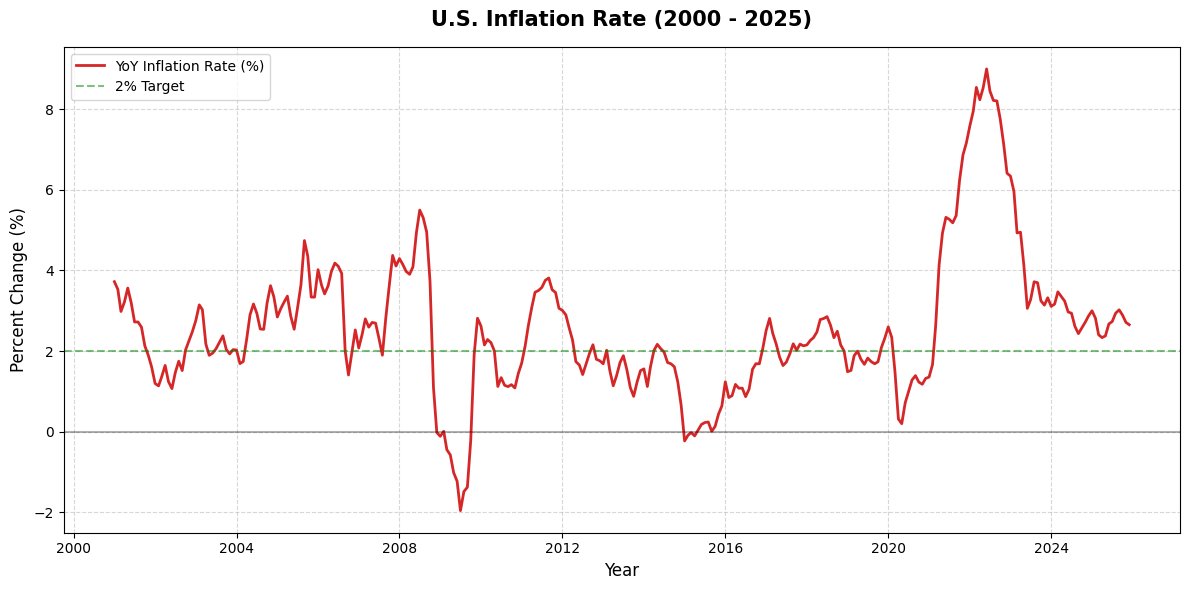

In [7]:
### Standard Inflation Visualization
plt.figure(figsize=(12, 6))

plt.plot(df_standard['Date'], df_standard['Standard_YoY'], color='#d62728', linewidth=2, label='YoY Inflation Rate (%)')

plt.axhline(0, color='black', linestyle='-', alpha=0.3)
plt.axhline(2, color='green', linestyle='--', alpha=0.5, label='2% Target') # FED's 2% target
plt.title('U.S. Inflation Rate (2000 - 2025)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percent Change (%)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

### Core Inflation

In [8]:
# Data Cleaning
core_df = pd.read_csv('CPI_Data/all items less food and energy adjusted.csv')

core_df = process_cpi_data(core_df, 'Core')
core_df


C:\Users\HP\AppData\Local\Temp\ipykernel_1644\2947928794.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Label'])


,Series ID,Year,Period,Value,Date,Core_YoY
0,CUSR0000SA0L1E,2000,M01,179.300,2000-01-01,NaN
1,CUSR0000SA0L1E,2000,M02,179.400,2000-02-01,NaN
2,CUSR0000SA0L1E,2000,M03,180.000,2000-03-01,NaN
3,CUSR0000SA0L1E,2000,M04,180.300,2000-04-01,NaN
4,CUSR0000SA0L1E,2000,M05,180.700,2000-05-01,NaN
...,...,...,...,...,...,...
307,CUSR0000SA0L1E,2025,M08,329.793,2025-08-01,3.112191
308,CUSR0000SA0L1E,2025,M09,330.542,2025-09-01,3.025543
309,CUSR0000SA0L1E,2025,M10,330.805,2025-10-01,2.834113
310,CUSR0000SA0L1E,2025,M11,331.068,2025-11-01,2.618879


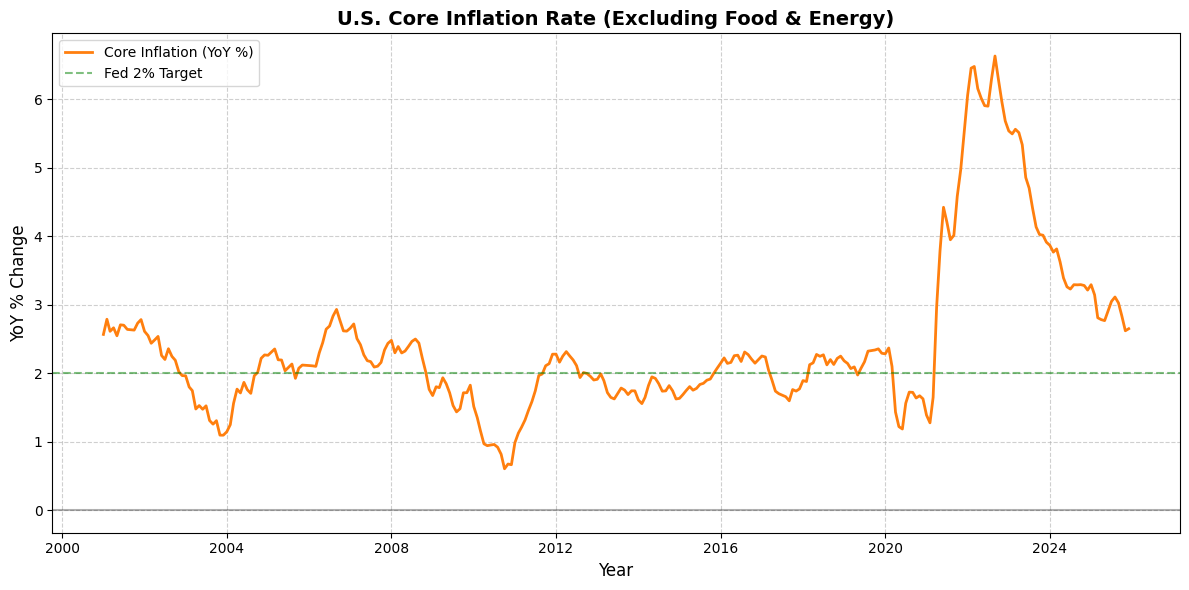

In [9]:
#Core inflation visualization
plt.figure(figsize=(12, 6))
plt.plot(core_df['Date'], core_df['Core_YoY'], color='#ff7f0e', linewidth=2, label='Core Inflation (YoY %)')
plt.axhline(0, color='black', linestyle='-', alpha=0.3)
plt.axhline(2, color='green', linestyle='--', alpha=0.5, label='Fed 2% Target')
plt.title('U.S. Core Inflation Rate (Excluding Food & Energy)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('YoY % Change', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### Supercore Inflation

In [10]:
supercore_df = pd.read_csv('CPI_Data/services_less_rent_of_shelter_adjusted.csv')
supercore_df = process_cpi_data(supercore_df,'Supercore')
supercore_df


C:\Users\HP\AppData\Local\Temp\ipykernel_1644\2947928794.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Label'])


,Series ID,Year,Period,Value,Date,Supercore_YoY
0,CUSR0000SASL2RS,2000,M01,198.900,2000-01-01,NaN
1,CUSR0000SASL2RS,2000,M02,199.500,2000-02-01,NaN
2,CUSR0000SASL2RS,2000,M03,200.100,2000-03-01,NaN
3,CUSR0000SASL2RS,2000,M04,200.700,2000-04-01,NaN
4,CUSR0000SASL2RS,2000,M05,201.300,2000-05-01,NaN
...,...,...,...,...,...,...
307,CUSR0000SASL2RS,2025,M08,433.888,2025-08-01,4.043143
308,CUSR0000SASL2RS,2025,M09,434.715,2025-09-01,3.698376
309,CUSR0000SASL2RS,2025,M10,435.634,2025-10-01,3.509693
310,CUSR0000SASL2RS,2025,M11,436.553,2025-11-01,3.541324


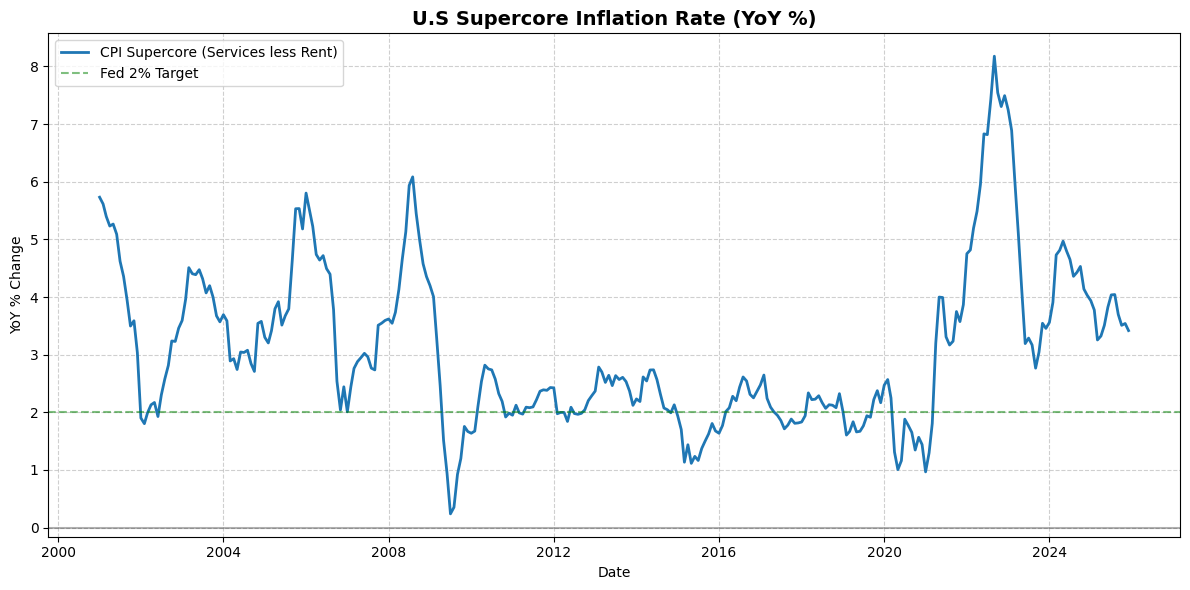

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(supercore_df['Date'], supercore_df['Supercore_YoY'], color='#1f77b4', linewidth=2, label='CPI Supercore (Services less Rent)')
plt.axhline(0, color='black', alpha=0.3)
plt.axhline(2, color='green', linestyle='--', alpha=0.5, label='Fed 2% Target')
plt.title('U.S Supercore Inflation Rate (YoY %)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('YoY % Change')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
### Merge datasets (Standard, Core, Supercore)

df_subset = df_standard[['Date', 'Standard_YoY']]
core_df_subset = core_df[['Date', 'Core_YoY']]
supercore_df_subset = supercore_df[['Date', 'Supercore_YoY']]

merged_inflation = df_subset.merge(core_df_subset, on='Date').merge(supercore_df_subset, on='Date')

merged_inflation.columns= ['Date', 'Standard', 'Core', 'Supercore']
merged_inflation

,Date,Standard,Core,Supercore
0,2000-01-01,NaN,NaN,NaN
1,2000-02-01,NaN,NaN,NaN
2,2000-03-01,NaN,NaN,NaN
3,2000-04-01,NaN,NaN,NaN
4,2000-05-01,NaN,NaN,NaN
...,...,...,...,...
307,2025-08-01,2.939220,3.112191,4.043143
308,2025-09-01,3.022700,3.025543,3.698376
309,2025-10-01,2.894975,2.834113,3.509693
310,2025-11-01,2.711969,2.618879,3.541324


# U.S inflation comparison 

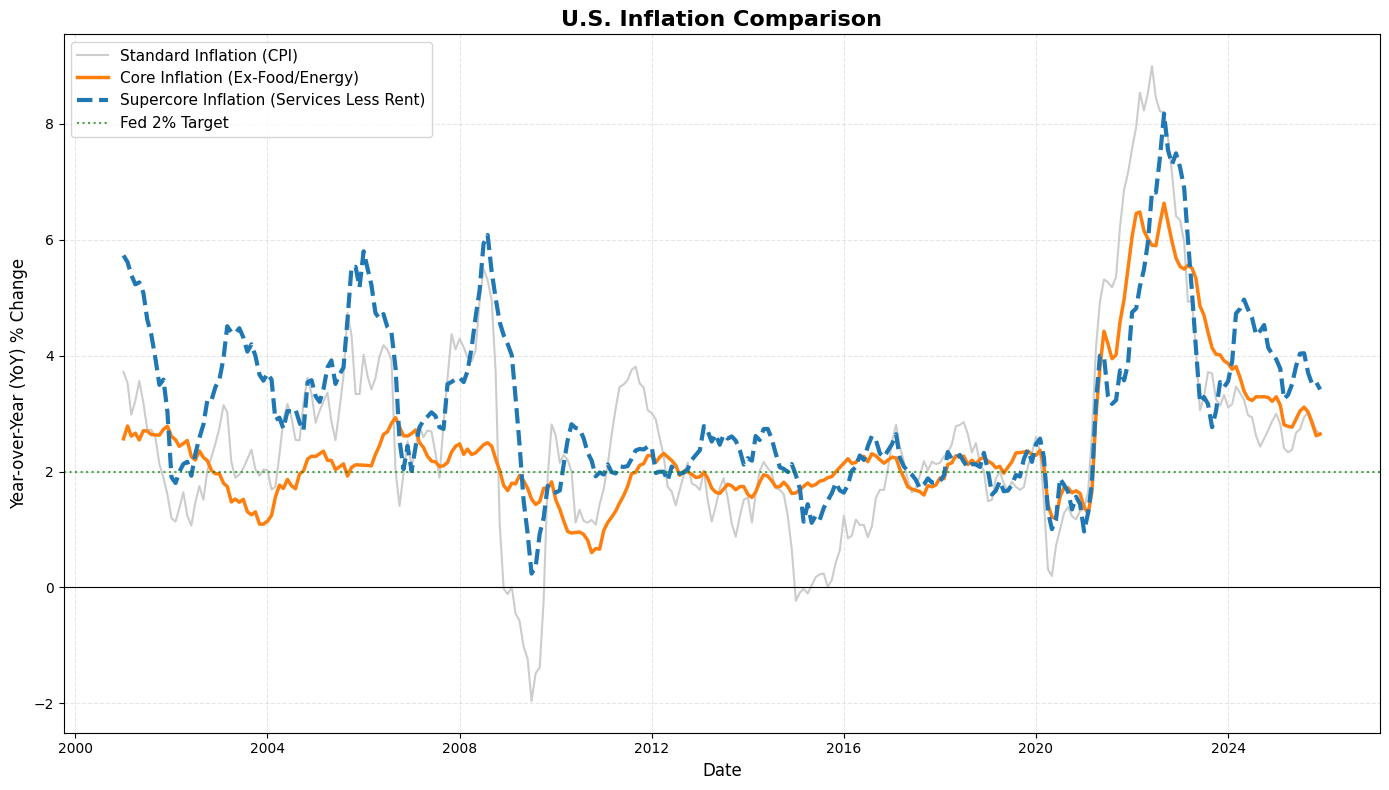

          Date  Standard      Core  Supercore
307 2025-08-01  2.939220  3.112191   4.043143
308 2025-09-01  3.022700  3.025543   3.698376
309 2025-10-01  2.894975  2.834113   3.509693
310 2025-11-01  2.711969  2.618879   3.541324
311 2025-12-01  2.653312  2.648966   3.418096


In [13]:
plt.figure(figsize=(14, 8))

plt.plot(merged_inflation['Date'], merged_inflation['Standard'], label='Standard Inflation (CPI)', color='silver', alpha=0.8)
plt.plot(merged_inflation['Date'], merged_inflation['Core'], label='Core Inflation (Ex-Food/Energy)', color='#ff7f0e', linewidth=2.5)
plt.plot(merged_inflation['Date'], merged_inflation['Supercore'], label='Supercore Inflation (Services Less Rent)', color='#1f77b4', linewidth=3.0, linestyle='--')

# Formatting and reference lines
plt.axhline(0, color='black', linewidth=0.8)
plt.axhline(2, color='green', linestyle=':', label='Fed 2% Target', alpha=0.7)
plt.title('U.S. Inflation Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Year-over-Year (YoY) % Change', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

# Displaying the most recent merged values for confirmation
print(merged_inflation.tail())

Standard - includes everything
Core - removes Food and Energy
Supercore - removing Food, Energy, and Housing/Shelter, focuses primarily on the cost of services


# Categorical Inflation Analysis

Official 8 Major Expenditure Groups 

- Housing
- Food and Beverages
- Transportation
- Medical Care
- Education and Communication
- Recreation
- Apparel
- Other Goods and services

- Energy (Special Aggregate)

In [14]:
category_files = {
    'Housing': 'CPI_Data/housing.xlsx',
    'Food': 'CPI_Data/food_beverages.xlsx',
    'Transportation': 'CPI_Data/Transportation.xlsx',
    'Medical Care': 'CPI_Data/Medical_care.xlsx',
    'Education': 'CPI_Data/Education.xlsx',
    'Communication': 'CPI_Data/Communication.xlsx',
    'Recreation': 'CPI_Data/Recreation.xlsx',
    'Apparel': 'CPI_Data/Apparel.xlsx',
    'other_goods': 'CPI_Data/Other_goods.xlsx',
    'Energy': 'CPI_Data/Energy.xlsx'}



In [15]:
all_data = []

for name, file in category_files.items():
    df_temp = pd.read_excel(file,header=11)

    df_temp['Date'] = pd.to_datetime(df_temp['Year'].astype(str) + ' ' + df_temp['Period'].str.replace('M', ''), format='%Y %m')
    df_temp = df_temp.sort_values('Date')
    df_temp['Value'] = pd.to_numeric(df_temp['Value'], errors='coerce')
    
    # Calculate YoY
    df_temp[f'{name}_YoY'] = df_temp['Value'].pct_change(12) * 100
    # Calculate Index from base 100 at start (Jan 2000)
    first_val = df_temp['Value'].iloc[0]
    df_temp[f'{name}_Index'] = (df_temp['Value'] / first_val) * 100
    
    all_data.append(df_temp[['Date', f'{name}_YoY', f'{name}_Index']])

merged_category = all_data[0]
for d in all_data[1:]:
    merged_category = merged_category.merge(d, on='Date', how='outer')

merged_category

c:\Anaconda_aiclass\envs\mlb\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\HP\AppData\Local\Temp\ipykernel_1644\3012626932.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_temp[f'{name}_YoY'] = df_temp['Value'].pct_change(12) * 100
c:\Anaconda_aiclass\envs\mlb\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\HP\AppData\Local\Temp\ipykernel_1644\3012626932.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a futur

,Date,Housing_YoY,Housing_Index,Food_YoY,Food_Index,Transportation_YoY,Transportation_Index,Medical Care_YoY,Medical Care_Index,Education_YoY,...,Communication_YoY,Communication_Index,Recreation_YoY,Recreation_Index,Apparel_YoY,Apparel_Index,other_goods_YoY,other_goods_Index,Energy_YoY,Energy_Index
0,2000-01-01,NaN,100.000000,NaN,100.000000,NaN,100.000000,NaN,100.000000,NaN,...,NaN,100.000000,NaN,100.000000,NaN,100.000000,NaN,100.000000,NaN,100.000000
1,2000-02-01,NaN,100.480480,NaN,100.361228,NaN,100.603622,NaN,100.352113,NaN,...,NaN,98.645833,NaN,100.097752,NaN,99.770467,NaN,100.717523,NaN,103.304348
2,2000-03-01,NaN,100.720721,NaN,100.602047,NaN,103.018109,NaN,100.821596,NaN,...,NaN,98.125000,NaN,100.391007,NaN,99.693956,NaN,101.132931,NaN,108.086957
3,2000-04-01,NaN,100.840841,NaN,100.662252,NaN,102.012072,NaN,101.095462,NaN,...,NaN,97.708333,NaN,100.293255,NaN,99.311400,NaN,102.605740,NaN,105.130435
4,2000-05-01,NaN,101.081081,NaN,101.023480,NaN,101.945003,NaN,101.408451,NaN,...,NaN,97.604167,NaN,100.684262,NaN,99.234889,NaN,101.963746,NaN,104.347826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,2025-08-01,3.981156,209.589790,3.117751,203.663456,1.059199,182.183099,3.449547,228.416275,3.547286,...,-2.085125,75.916667,2.312561,138.261975,0.251556,100.927314,3.873836,220.295695,0.388961,240.813913
308,2025-09-01,3.860646,209.919520,3.050976,204.163155,1.772430,183.696848,3.283336,228.911189,3.064077,...,-1.725816,75.746875,3.059447,138.792766,-0.011288,101.661056,4.130368,221.319109,2.884665,244.452174
309,2025-10-01,3.480884,NaN,2.821633,NaN,1.697986,NaN,3.039968,NaN,2.817087,...,-1.273505,NaN,2.663755,NaN,0.884546,NaN,3.783505,NaN,3.114489,NaN
310,2025-11-01,3.504636,210.673273,2.585480,204.311860,1.497619,183.954393,2.890400,229.112285,2.862917,...,0.313724,76.273958,1.791482,138.022483,0.076623,100.929610,3.927681,222.594411,4.142738,247.101739


In [16]:
merged_category.to_csv('merged_categorical_inflation_rates.csv')

# 1. Plot Cumulative Growth (Index)

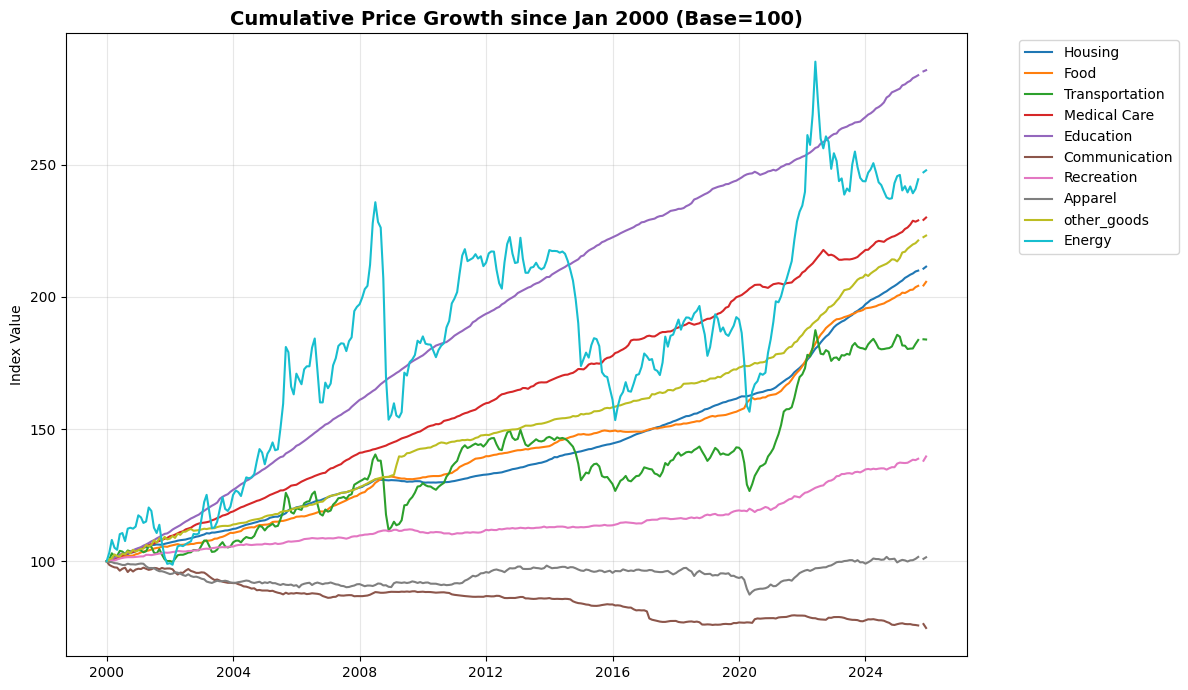

In [17]:
plt.figure(figsize=(12, 7))
index_cols = [c for c in merged_category.columns if '_Index' in c]
for col in index_cols:
    plt.plot(merged_category['Date'], merged_category[col], label=col.replace('_Index', ''))

plt.title('Cumulative Price Growth since Jan 2000 (Base=100)', fontsize=14, fontweight='bold')
plt.ylabel('Index Value')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

How it is calculated
- the starting point (January 2000) as the baseline
- take the CPI value for every subsequent month and divide it by that first value from Jan 2000, then multiply by 100
- Cumulative Growth Tracking: Because every line starts at exactly 100, the Y-axis represents the percentage change plus 100.

Example: If the Education line hits 300, it means the price is exactly 3 times (200% more) what it was in 2000.

Example: If the Apparel line is at 98, it means clothes are 2% cheaper than they were in 2000.

# 2. Plot Volatility (Boxplot of YoY)

C:\Users\HP\AppData\Local\Temp\ipykernel_1644\350017703.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted_yoy, x='Category', y='YoY', palette='Set2')


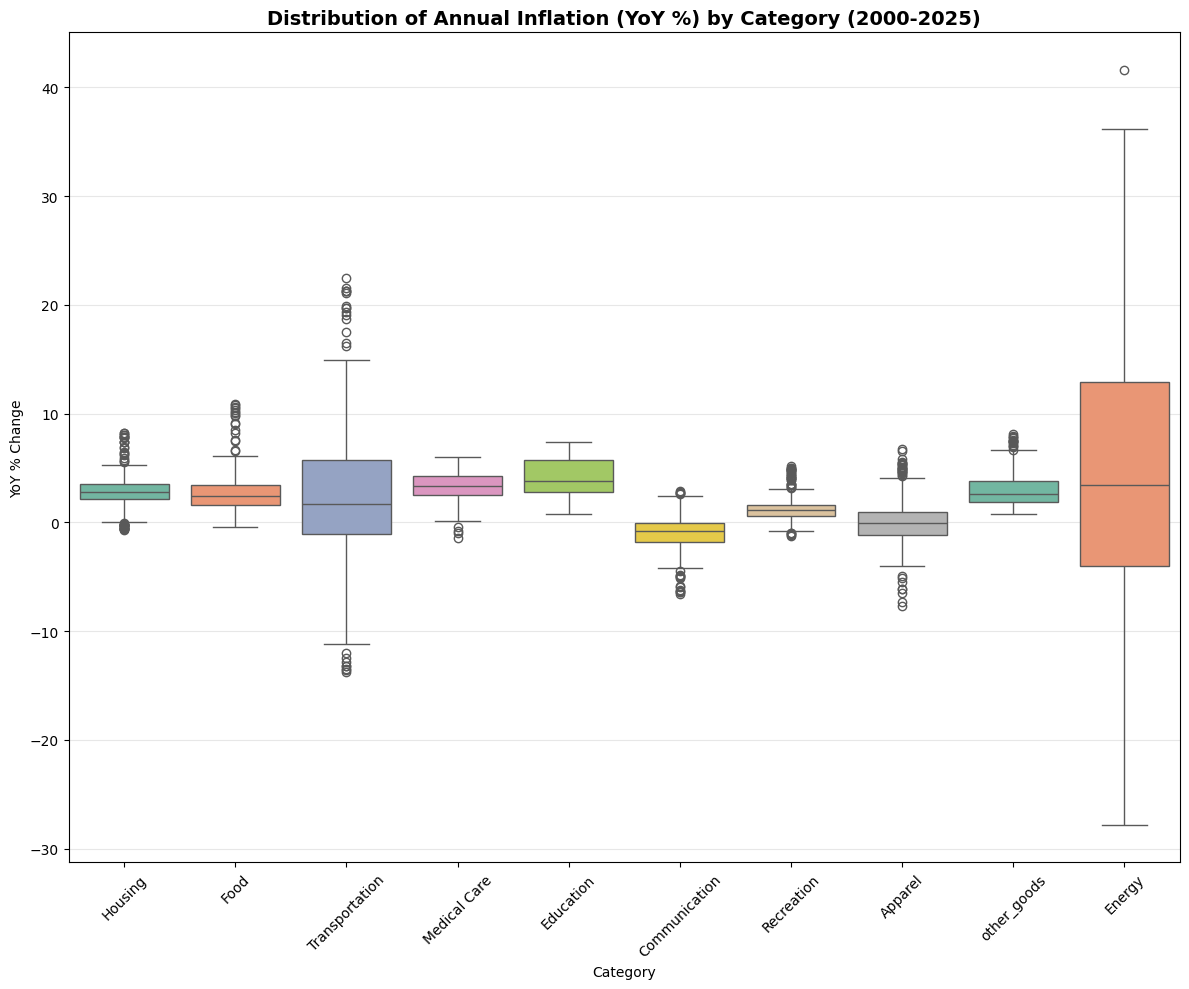

In [18]:
plt.figure(figsize=(12, 10))
yoy_cols = [c for c in merged_category.columns if '_YoY' in c]
melted_yoy = merged_category.melt(id_vars='Date', value_vars=yoy_cols, var_name='Category', value_name='YoY')
melted_yoy['Category'] = melted_yoy['Category'].str.replace('_YoY', '')

sns.boxplot(data=melted_yoy, x='Category', y='YoY', palette='Set2')
plt.title('Distribution of Annual Inflation (YoY %) by Category (2000-2025)', fontsize=14, fontweight='bold')
plt.ylabel('YoY % Change')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
summary = merged_category[yoy_cols].describe().T[['mean', 'std', 'min', 'max']]
summary.index = summary.index.str.replace('_YoY', '')
print(summary.sort_values('std', ascending=False))

                    mean        std        min        max
Energy          4.106873  12.982438 -27.796894  41.578716
Transportation  2.547770   6.791032 -13.732564  22.505629
Apparel         0.088019   2.327741  -7.692059   6.731037
Food            2.833233   2.064246  -0.467411  10.918788
Communication  -0.971530   1.723721  -6.563131   2.842868
Education       4.150099   1.642851   0.780599   7.347254
Housing         2.917261   1.630542  -0.699108   8.229025
other_goods     3.100062   1.593198   0.799106   8.079411
Recreation      1.263830   1.201847  -1.300492   5.153316
Medical Care    3.260407   1.201300  -1.423392   5.991263


# 3. Line Plot: YoY Inflation by Category

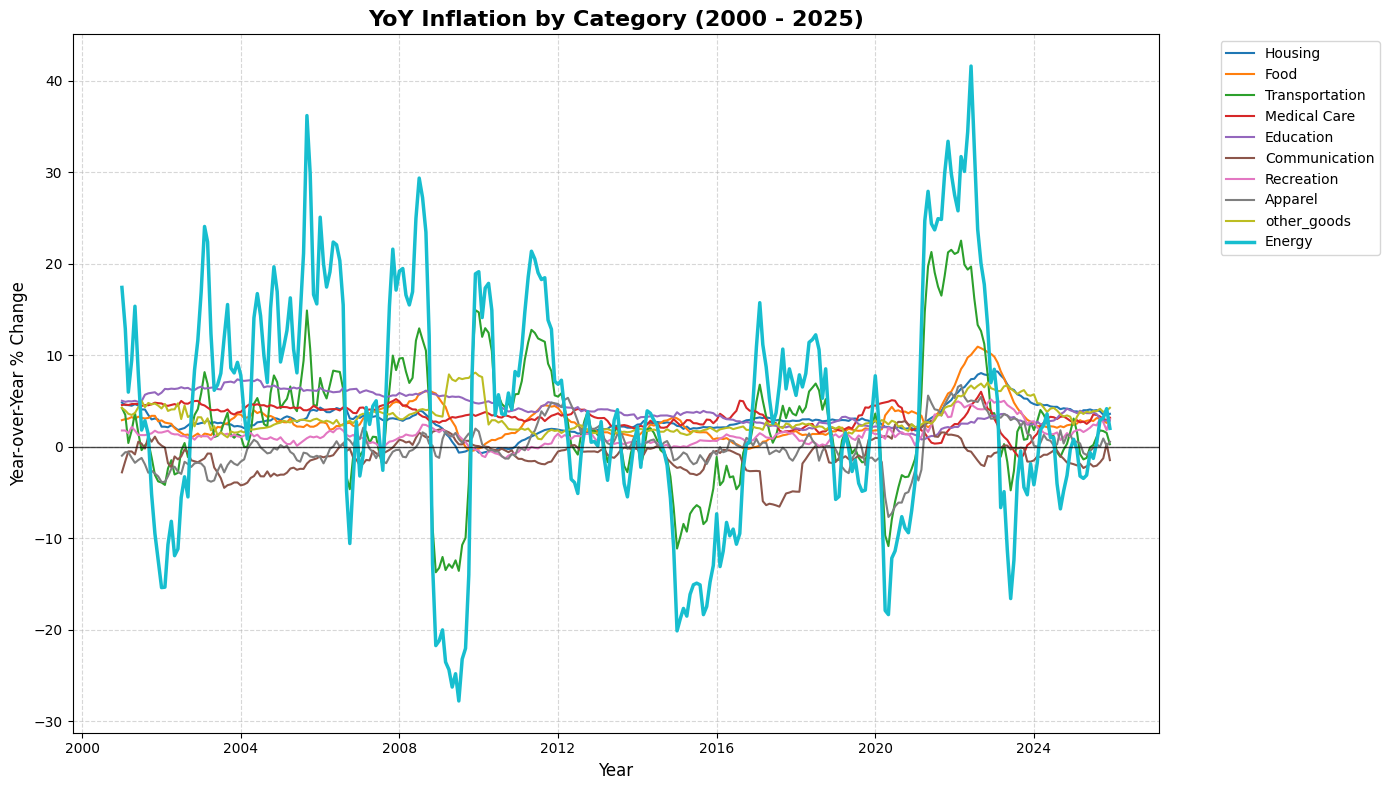

In [20]:
merged_category_1 = merged_category.set_index('Date')
yoy_cols = [c for c in merged_category_1.columns if '_YoY' in c]


plt.figure(figsize=(14, 8))
for col in yoy_cols:
    label = col.replace('_YoY', '')
    #a thicker line for Energy to highlight it
    linewidth = 2.5 if 'Energy' in col else 1.5
    plt.plot(merged_category_1.index, merged_category_1[col], label=label, linewidth=linewidth)

plt.axhline(0, color='black', linewidth=1, alpha=0.7)
plt.title('YoY Inflation by Category (2000 - 2025)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Year-over-Year % Change', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. Bar Plot: Price Volatility 
(Standard Deviation of YoY Changes)

C:\Users\HP\AppData\Local\Temp\ipykernel_1644\2794763093.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=volatility.index, y=volatility.values, palette=colors)


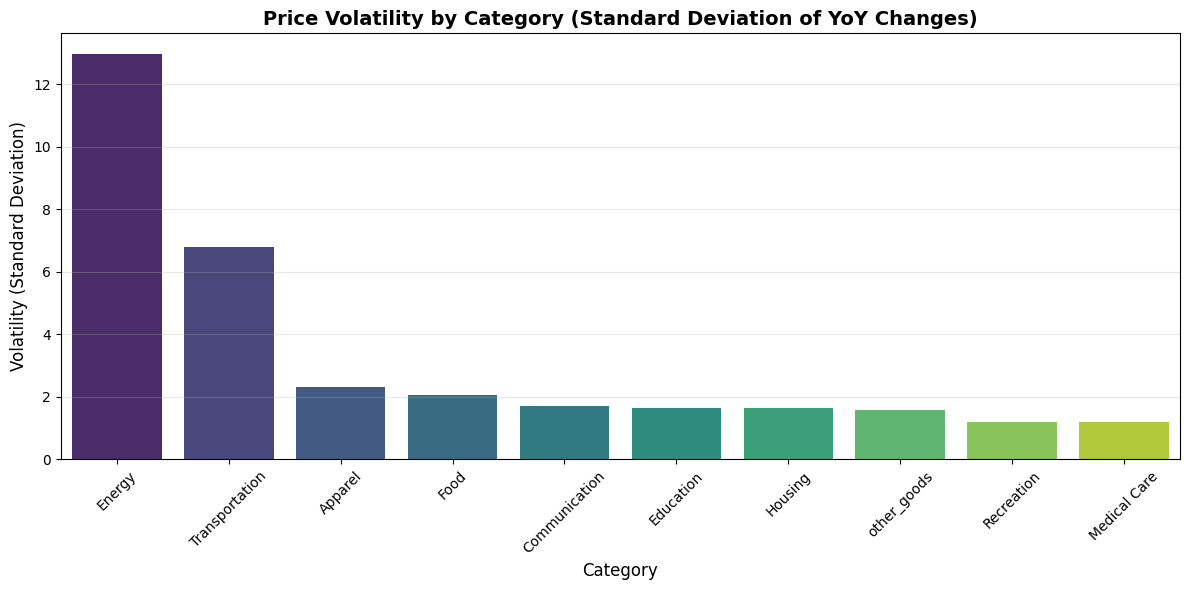

In [21]:
volatility = merged_category[yoy_cols].std().sort_values(ascending=False)
volatility.index = [i.replace('_YoY', '') for i in volatility.index]

plt.figure(figsize=(12, 6))
colors = sns.color_palette("viridis", len(volatility))
sns.barplot(x=volatility.index, y=volatility.values, palette=colors)

plt.title('Price Volatility by Category (Standard Deviation of YoY Changes)', fontsize=14, fontweight='bold')
plt.ylabel('Volatility (Standard Deviation)', fontsize=12)
plt.xlabel('Category', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#  5. CATEGORY CORRELATION HEATMAP 

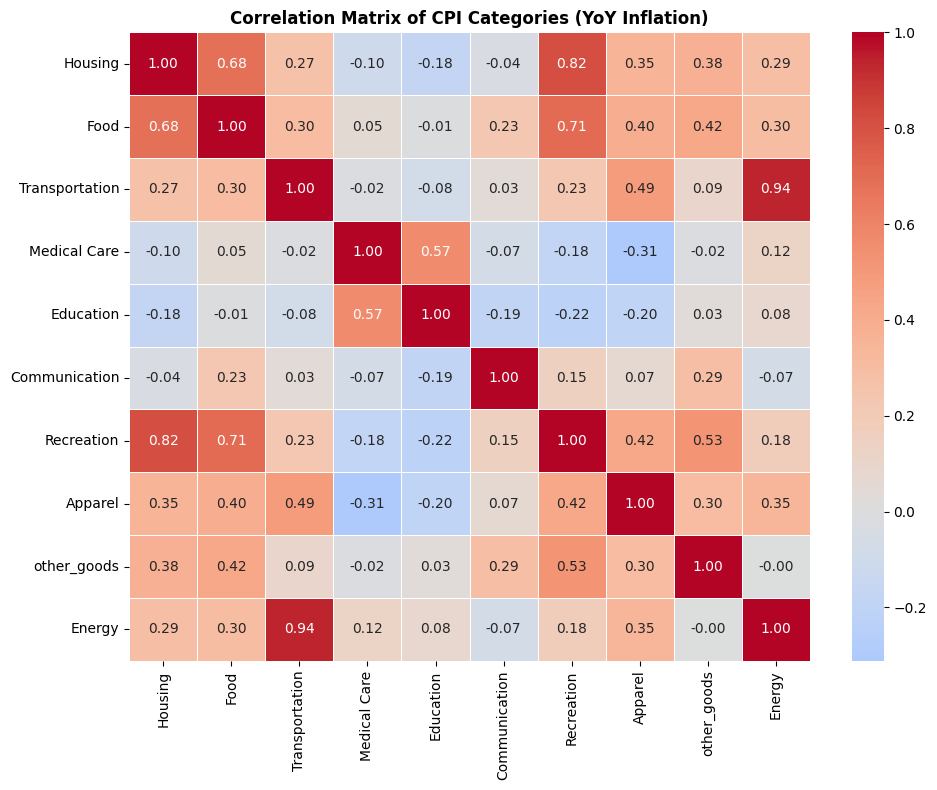

In [ ]:
yoy_cols = [col for col in merged_category.columns if '_YoY' in col]
df_yoy = merged_category[['Date'] + yoy_cols].copy()

# 2. Clean names for better plotting (Remove the "_YoY" suffix)
df_yoy.columns = [c.replace('_YoY', '') for c in df_yoy.columns]

plt.figure(figsize=(10, 8))
# Drop Date for the correlation matrix
corr_matrix = df_yoy.drop(columns='Date').corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of CPI Categories (YoY Inflation)', fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Yearly Inflation Heatmap

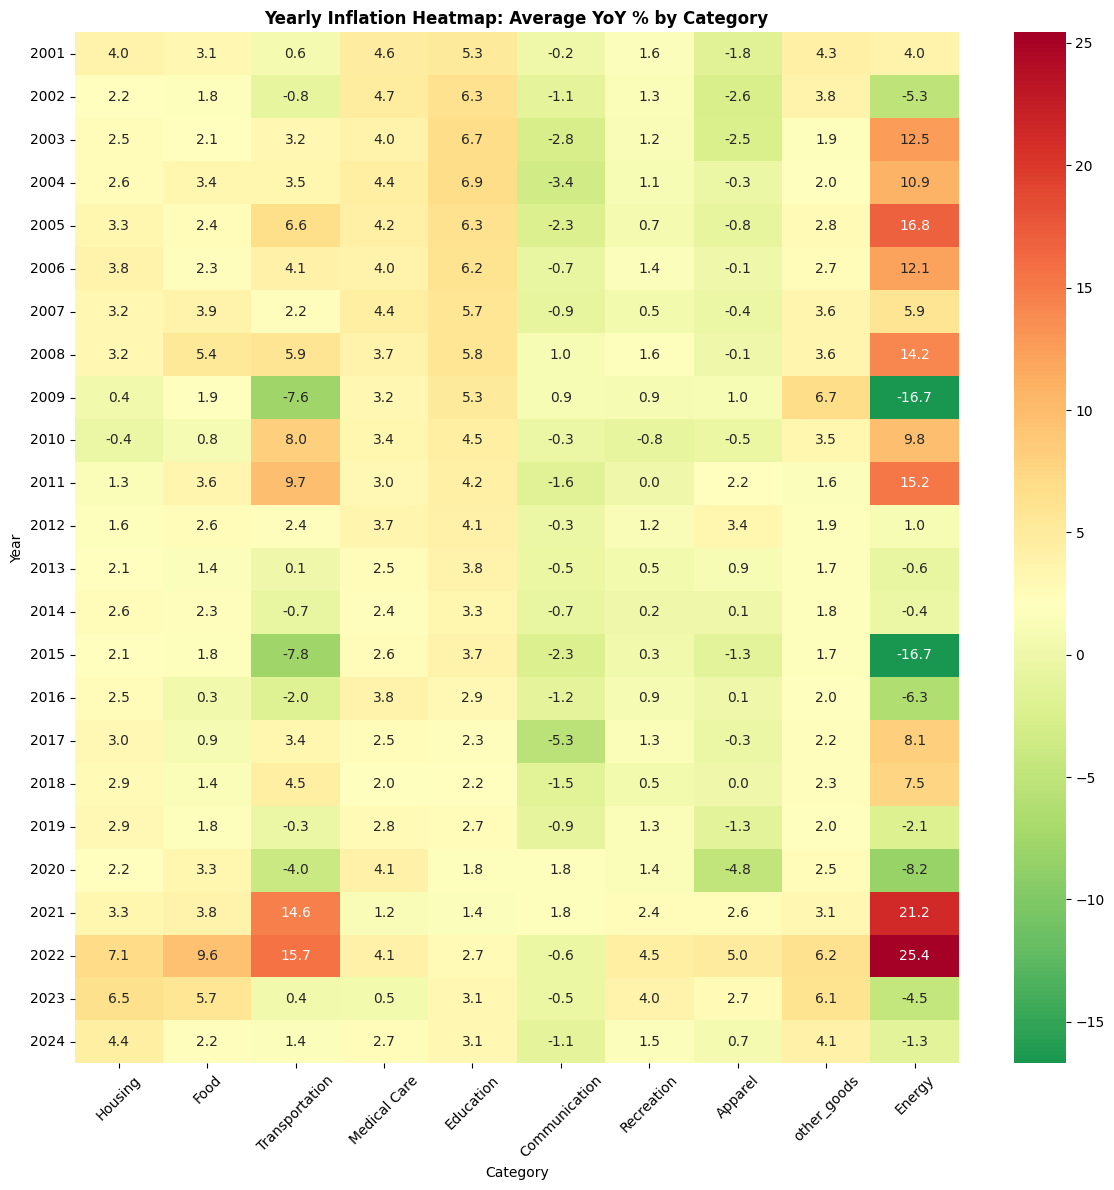

In [23]:
df_yoy['Year'] = pd.to_datetime(df_yoy['Date']).dt.year
df_yoy = df_yoy.dropna()
yearly_heatmap_data = df_yoy.groupby('Year').mean().drop(columns='Date', errors='ignore')

# Filter for full years (2000-2024) to avoid partial 2025 skewing the map
yearly_heatmap_data = yearly_heatmap_data[(yearly_heatmap_data.index >= 2000) & (yearly_heatmap_data.index <= 2024)]

plt.figure(figsize=(12, 12))
# Using RdYlGn_r: Red = High Inflation, Green = Low Inflation/Deflation
sns.heatmap(yearly_heatmap_data, annot=True, cmap='RdYlGn_r', center=2, fmt='.1f')
plt.title('Yearly Inflation Heatmap: Average YoY % by Category', fontweight='bold')
plt.ylabel('Year')
plt.xlabel('Category')
plt.yticks(rotation=0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Regional Inflation Analysis

In [25]:
region_files = {
    'Northeast': 'CPI_Data/Northeast.xlsx',
    'Midwest': 'CPI_Data/midwest.xlsx',
    'South': 'CPI_Data/south.xlsx',
    'West': 'CPI_Data/west.xlsx',
    }



In [26]:
def parse_region_data(file_path, region_name):
    df_raw = pd.read_excel(file_path, skiprows=11)
    
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    df_clean = df_raw[['Year'] + months].copy()
    
    #from wide to long
    df_long = df_clean.melt(id_vars='Year', var_name='Month', value_name='Value')
    
    # Create Date column
    df_long['Date'] = pd.to_datetime(df_long['Year'].astype(str) + ' ' + df_long['Month'])
    
    # Clean Value column
    df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')
    
    # Sort and set index
    df_long = df_long.sort_values('Date').dropna(subset=['Value'])
    df_long = df_long.set_index('Date')
    
    return df_long['Value'].rename(region_name)

regional_data = {}
for region, path in region_files.items():
    regional_data[region] = parse_region_data(path, region)

df_regions = pd.DataFrame(regional_data)
df_regions

c:\Anaconda_aiclass\envs\mlb\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\HP\AppData\Local\Temp\ipykernel_1644\2110805837.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_long['Date'] = pd.to_datetime(df_long['Year'].astype(str) + ' ' + df_long['Month'])
c:\Anaconda_aiclass\envs\mlb\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\HP\AppData\Local\Temp\ipykernel_1644\2110805837.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and

,Northeast,Midwest,South,West
Date,,,,
2000-01-01,176.200,164.900,164.100,171.000
2000-02-01,177.600,165.900,164.800,172.000
2000-03-01,178.500,167.100,166.500,173.500
2000-04-01,178.500,167.000,166.700,173.700
2000-05-01,178.400,167.500,166.700,174.000
...,...,...,...,...
2025-07-01,335.656,299.836,312.771,343.234
2025-08-01,336.936,300.753,313.558,344.096
2025-09-01,337.321,301.579,314.350,345.294


In [27]:
df_regional_yoy = (df_regions / df_regions.shift(12) - 1) * 100
df_regional_yoy = df_regional_yoy.dropna()
df_regional_yoy

,Northeast,Midwest,South,West
Date,,,,
2001-01-01,3.405221,4.244997,3.168800,4.269006
2001-02-01,2.927928,3.737191,3.276699,4.244186
2001-03-01,2.913165,2.752843,2.462462,3.804035
2001-04-01,3.193277,3.473054,2.819436,3.857225
2001-05-01,3.475336,4.000000,2.999400,4.195402
...,...,...,...,...
2025-07-01,3.171154,2.593617,2.273240,3.019443
2025-08-01,3.310235,2.800803,2.550031,3.195158
2025-09-01,3.107080,3.087367,2.702579,3.299478


In [28]:
merged_regions = df_standard.merge(df_regional_yoy, on='Date', how='inner')

cols_to_keep = ['Date', 'Standard_YoY', 'Northeast', 'Midwest', 'South', 'West']
merged_regions = merged_regions[cols_to_keep]
merged_regions

,Date,Standard_YoY,Northeast,Midwest,South,West
0,2001-01-01,3.721205,3.405221,4.244997,3.168800,4.269006
1,2001-02-01,3.529412,2.927928,3.737191,3.276699,4.244186
2,2001-03-01,2.982456,2.913165,2.752843,2.462462,3.804035
3,2001-04-01,3.218256,3.193277,3.473054,2.819436,3.857225
4,2001-05-01,3.563084,3.475336,4.000000,2.999400,4.195402
...,...,...,...,...,...,...
294,2025-07-01,2.731801,3.171154,2.593617,2.273240,3.019443
295,2025-08-01,2.939220,3.310235,2.800803,2.550031,3.195158
296,2025-09-01,3.022700,3.107080,3.087367,2.702579,3.299478
297,2025-11-01,2.711969,3.012330,2.901218,2.185807,2.923559


In [29]:
merged_regions.to_csv('merged_regional_inflation.csv')

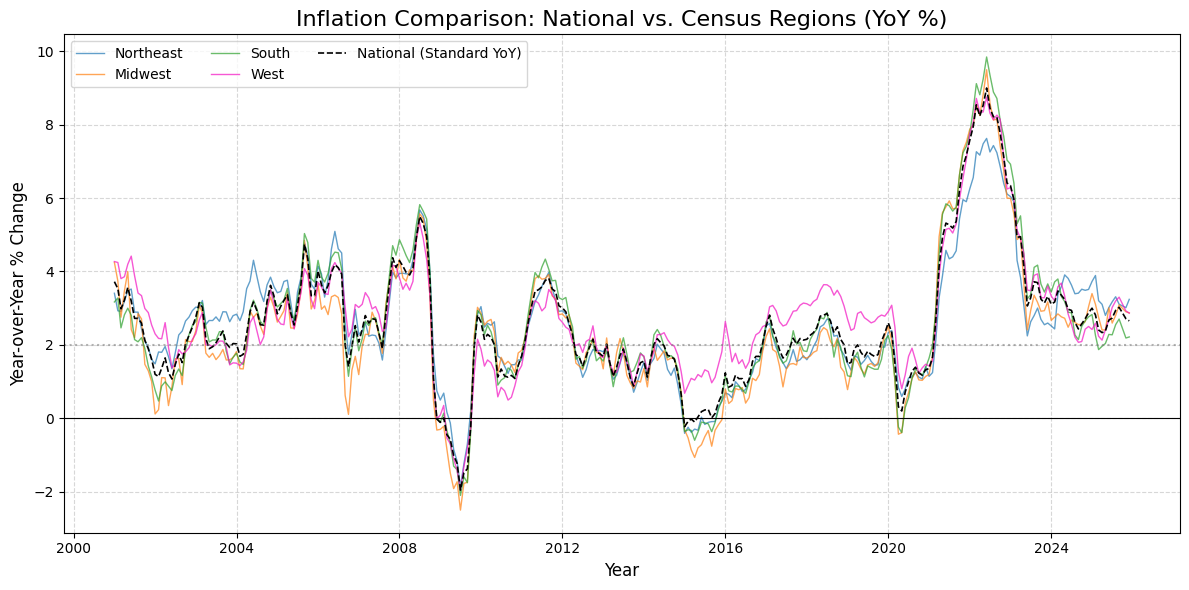

In [30]:
colors = {
    'Northeast': '#1f77b4',  # Blue
    'Midwest': '#ff7f0e',    # Orange
    'South': '#2ca02c',      # Green
    'West': "#f311c2"        # Red
}

plt.figure(figsize=(12, 6))
# Plot Regional lines
for region, color in colors.items():
    plt.plot(merged_regions['Date'], merged_regions[region], label=region, color=color, alpha=0.7, linewidth=1)

# Plot National line (Standard YoY)
plt.plot(merged_regions['Date'], merged_regions['Standard_YoY'], label='National (Standard YoY)', color='black', linewidth=1.2, linestyle='--')

# Styling
plt.title('Inflation Comparison: National vs. Census Regions (YoY %)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Year-over-Year % Change', fontsize=12)
plt.legend(loc='upper left', ncol=3, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linewidth=0.8) # Baseline
plt.axhline(2, color='gray', linestyle=':', alpha=0.6, label='2% Target')

# Final layout
plt.tight_layout()
plt.show()

# Show first few rows of the data used for the plot to confirm
